<a href="https://colab.research.google.com/github/Adi324-Code/Machine-Learning/blob/main/Facemask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle




In [ ]:
! export KAGGLE_API_TOKEN=KGAT_d9a1c349503386c9a79ec83d8c862641

In [ ]:
! mkdir -p ~/.kaggle && echo KGAT_d9a1c349503386c9a79ec83d8c862641 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 118MB/s]



In [ ]:
!unzip face-mask-dataset.zip -d face_mask_data

Streaming output truncated to the last 5000 lines.
  inflating: face_mask_data/data/with_mask/with_mask_3297.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3298.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3299.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_33.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_330.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3300.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3301.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3302.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3303.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3304.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3305.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3306.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3307.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_3308.jpg  
  inflating: face_mask_data/data/with_mask/with_mask_330

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.image as mpimg
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_file=os.listdir("/content/face_mask_data/data/with_mask")

In [ ]:
print(with_mask_file[:10])

['with_mask_1397.jpg', 'with_mask_35.jpg', 'with_mask_3375.jpg', 'with_mask_2546.jpg', 'with_mask_2463.jpg', 'with_mask_3431.jpg', 'with_mask_101.jpg', 'with_mask_3421.jpg', 'with_mask_3183.jpg', 'with_mask_2273.jpg']


In [ ]:
print(with_mask_file[-10:])

['with_mask_3410.jpg', 'with_mask_1891.jpg', 'with_mask_2802.jpg', 'with_mask_2779.jpg', 'with_mask_2439.jpg', 'with_mask_2827.jpg', 'with_mask_2824.jpg', 'with_mask_741.jpg', 'with_mask_1565.jpg', 'with_mask_1787.jpg']


In [ ]:
without_mask_file=os.listdir("/content/face_mask_data/data/without_mask")

In [ ]:
print(without_mask_file[:10])

['without_mask_350.jpg', 'without_mask_3014.jpg', 'without_mask_1525.jpg', 'without_mask_3140.jpg', 'without_mask_3702.jpg', 'without_mask_1066.jpg', 'without_mask_2885.jpg', 'without_mask_2881.jpg', 'without_mask_851.jpg', 'without_mask_3610.jpg']


In [ ]:
print("with_mask:",len(with_mask_file))
print("without_mask:",len(without_mask_file))

with_mask: 3725
without_mask: 3828


In [ ]:
with_mask_label=[1]*3725
without_mask_label=[0]*3828

In [ ]:
print(with_mask_label[:10])
print(without_mask_label[-10:])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
label_total=with_mask_label+without_mask_label
print(len(label_total))
print(label_total[:10])
print(label_total[-10:])

7553
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


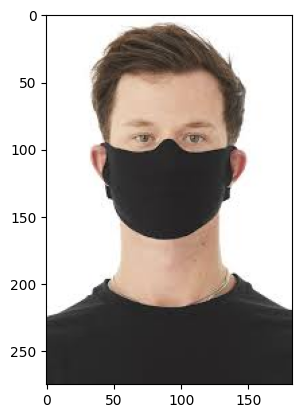

In [ ]:
img=mpimg.imread("/content/face_mask_data/data/with_mask/with_mask_794.jpg")
imgplt=plt.imshow(img)
plt.show()

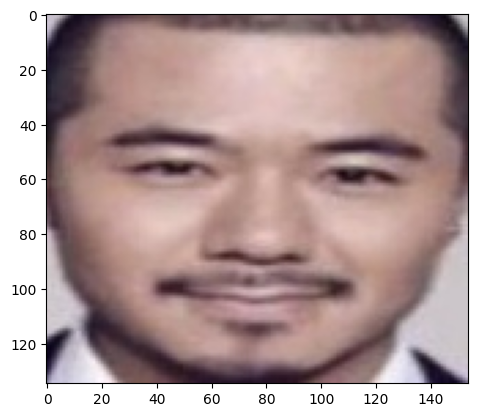

In [ ]:
img2=mpimg.imread("/content/face_mask_data/data/without_mask/without_mask_10.jpg")
imgplt=plt.imshow(img2)
plt.show()

Image **processing**

converting the img to numpy array

In [ ]:
with_mask_path='/content/face_mask_data/data/with_mask/'
data=[]
for img_file in with_mask_file:

  image=Image.open(with_mask_path+img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

without_mask_path='/content/face_mask_data/data/without_mask/'

for img_file in without_mask_file:

  image=Image.open(without_mask_path+img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[ 43,  41,  44],
        [ 44,  42,  45],
        [ 41,  39,  42],
        ...,
        [216, 206, 215],
        [231, 224, 232],
        [241, 235, 245]],

       [[ 43,  41,  44],
        [ 44,  42,  45],
        [ 42,  40,  43],
        ...,
        [212, 202, 211],
        [224, 217, 225],
        [236, 230, 240]],

       [[ 44,  39,  43],
        [ 46,  41,  45],
        [ 43,  38,  42],
        ...,
        [212, 202, 211],
        [221, 213, 221],
        [231, 225, 235]],

       ...,

       [[ 35,  11,   9],
        [ 38,  14,  10],
        [ 42,  16,  11],
        ...,
        [225, 223, 236],
        [232, 230, 243],
        [238, 236, 249]],

       [[ 30,   9,   6],
        [ 34,  13,   8],
        [ 40,  15,  11],
        ...,
        [222, 220, 233],
        [229, 227, 240],
        [238, 236, 249]],

       [[ 28,   9,   5],
        [ 35,  13,   8],
        [ 40,  15,  11],
        ...,
        [220, 218, 231],
        [227, 225, 238],
        [236, 234, 247]]], dtype=uint8)
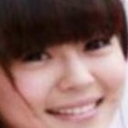

In [ ]:
data[5999]

In [ ]:
type(data[5])

numpy.ndarray

In [ ]:
data[5].shape

(128, 128, 3)

In [ ]:
X=np.array(data)
Y=np.array(label_total)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
print(X.shape)

(7553, 128, 128, 3)


In [ ]:
print(Y.shape)
print(Y)

(7553,)
[1 1 1 ... 0 0 0]


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
print(X_train)

[[[[198 183 164]
   [198 183 164]
   [198 183 164]
   ...
   [200 205 226]
   [203 207 230]
   [207 210 230]]

  [[200 185 166]
   [200 185 166]
   [200 185 166]
   ...
   [189 195 220]
   [192 198 224]
   [194 200 224]]

  [[202 187 168]
   [202 187 168]
   [202 187 168]
   ...
   [176 184 214]
   [179 187 216]
   [179 189 218]]

  ...

  [[ 38  51  70]
   [ 33  46  64]
   [ 46  57  75]
   ...
   [157 159 171]
   [152 155 167]
   [151 153 166]]

  [[ 39  52  71]
   [ 32  45  63]
   [ 42  53  71]
   ...
   [164 166 178]
   [158 160 172]
   [156 158 171]]

  [[ 42  55  72]
   [ 35  48  65]
   [ 37  49  67]
   ...
   [170 171 182]
   [164 164 177]
   [161 162 175]]]


 [[[226 225 230]
   [236 235 240]
   [228 227 232]
   ...
   [127 126 126]
   [176 176 176]
   [208 208 208]]

  [[231 230 235]
   [240 239 244]
   [225 224 229]
   ...
   [109 109 109]
   [158 158 158]
   [201 201 201]]

  [[233 232 237]
   [240 239 244]
   [216 215 220]
   ...
   [ 89  89  89]
   [135 135 135]
   [190 190

In [ ]:
print(Y_train)
print(Y_test)

[1 0 1 ... 0 1 0]
[1 0 1 ... 1 0 0]


In [ ]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(6042, 128, 128, 3)
(6042,)
(1511, 128, 128, 3)
(1511,)


In [ ]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255
# so that all values lie betbeen 0 n 1....0 means black 1 mean black all others between them represent colurs

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes=2

In [ ]:
model=keras.Sequential()

In [ ]:
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes,activation="sigmoid"))


In [ ]:
# compile

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8014 - loss: 0.4436 - val_accuracy: 0.8942 - val_loss: 0.2907
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8996 - loss: 0.2591 - val_accuracy: 0.8975 - val_loss: 0.2262
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9209 - loss: 0.1993 - val_accuracy: 0.9174 - val_loss: 0.2226
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9375 - loss: 0.1599 - val_accuracy: 0.9124 - val_loss: 0.2309
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9445 - loss: 0.1501 - val_accuracy: 0.9025 - val_loss: 0.2609


In [ ]:
loss,accuracy=model.evaluate(X_test_scaled,Y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9279 - loss: 0.2059


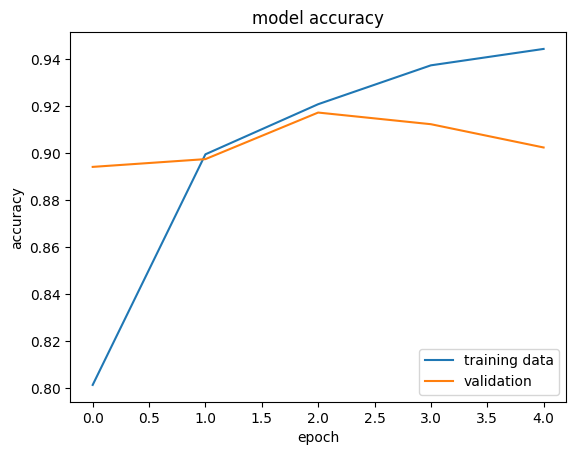

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")

plt.legend(["training data","validation"],loc="lower right")

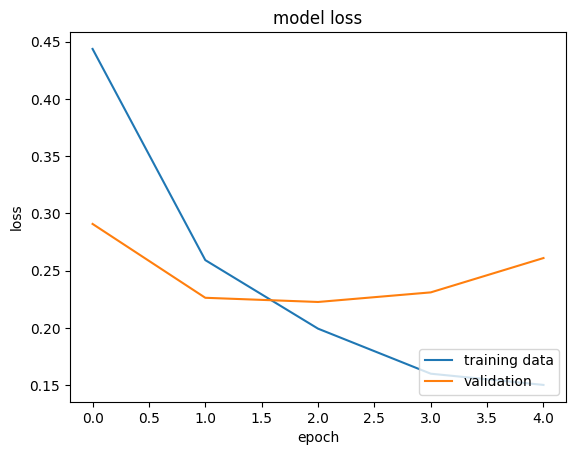

In [ ]:

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")

plt.legend(["training data","validation"],loc="lower right")

path of img: /content/Washable Organic Cotton Face Mask, Double-Layer White Reusable Mask with Adjustable Elastic, Eco-Friendly Protective Mask, Unisex Gift.png


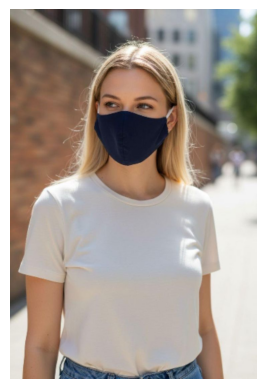

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
[[0.23856059 0.6751353 ]]
1
with mask


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_image_path = input("path of img: ")

input_image = cv2.imread(input_image_path)

if input_image is None:
    print("Image not loaded. Check the file path.")
else:
    input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
    plt.imshow(input_image_rgb)
    plt.axis("off")
    plt.show()

    input_image_resized = cv2.resize(input_image, (128, 128))
    input_image_scaled = input_image_resized / 255.0
    input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

    input_prediction = model.predict(input_image_reshaped)
    print(input_prediction)

    input_pred_label = np.argmax(input_prediction)
    print(input_pred_label)

    if input_pred_label == 1:
        print("with mask")
    else:
        print("without mask")

In [ ]:
model.save("facemask_model.h5")
